# 46 - Intermediate conf60 7-class

**Dataset:** Front-only conf60 (confidence >= 60%)
**Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import IntermediateFusion
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly_conf60" / "7class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 7
EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]

print(f"Dataset: {DATASET_DIR}")
print(f"Dataset Aug: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
GPU: Tesla T4
Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60
Dataset Aug: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class


In [2]:
def load_dataloaders(dataset_dir, batch_size=32):
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = EmotionMultimodalDataset(dataset_dir / f"X_{split}_images.npy", dataset_dir / f"X_{split}_landmarks.npy", dataset_dir / f"y_{split}.npy")
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split=="train"), num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(y)} | Val: {len(np.load(dataset_dir / 'y_val.npy'))} | Test: {len(np.load(dataset_dir / 'y_test.npy'))}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return loaders["train"], loaders["val"], loaders["test"]

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 5287 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
       angry: 27
     fearful: 2
   disgusted: 13
   surprised: 16


## Training B1, B2, B3


Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.3242     0.6143     1.2988    0.8238   0.1291   0.000100  (32.6s)


     2      0.6814     0.8551     0.9001    0.8238   0.1291   0.000100  (32.3s)


     3      0.5674     0.8559     0.8549    0.8187   0.1381   0.000100  (32.2s)


     4      0.5131     0.8561     0.7950    0.8273   0.1962   0.000100  (32.3s)


...

    23      0.2473     0.9179     0.7154    0.7893   0.2306   0.000050  (31.6s)


    24      0.2424     0.9213     0.7211    0.7910   0.2232   0.000050  (31.6s)


    25      0.2332     0.9249     0.7975    0.7288   0.2152   0.000050  (31.5s)


    26      0.2238     0.9268     0.7998    0.7427   0.2025   0.000050  (31.5s)


    27      0.2168     0.9329     0.7729    0.7686   0.2057   0.000050  (31.6s)

Early stopping at epoch 27. Best epoch: 12 (val_f1=0.2525)

Best: epoch 12, val_acc=0.8169, val_f1=0.2525
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/intermediate_b1.pth


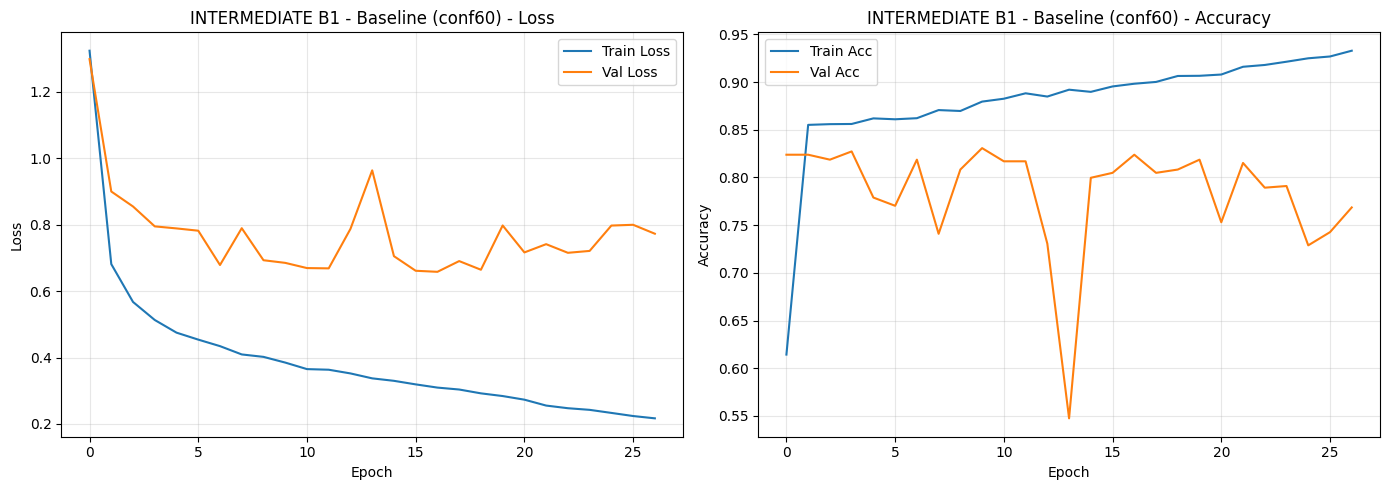

Test Loss: 0.5412
Test Accuracy: 0.7922
Test Macro F1: 0.2612
Test Weighted F1: 0.7914

Classification Report:
              precision    recall  f1-score   support

     neutral       0.89      0.86      0.87       688
       happy       0.60      0.70      0.65       183
         sad       0.31      0.30      0.31        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.79       929
   macro avg       0.26      0.27      0.26       929
weighted avg       0.79      0.79      0.79       929



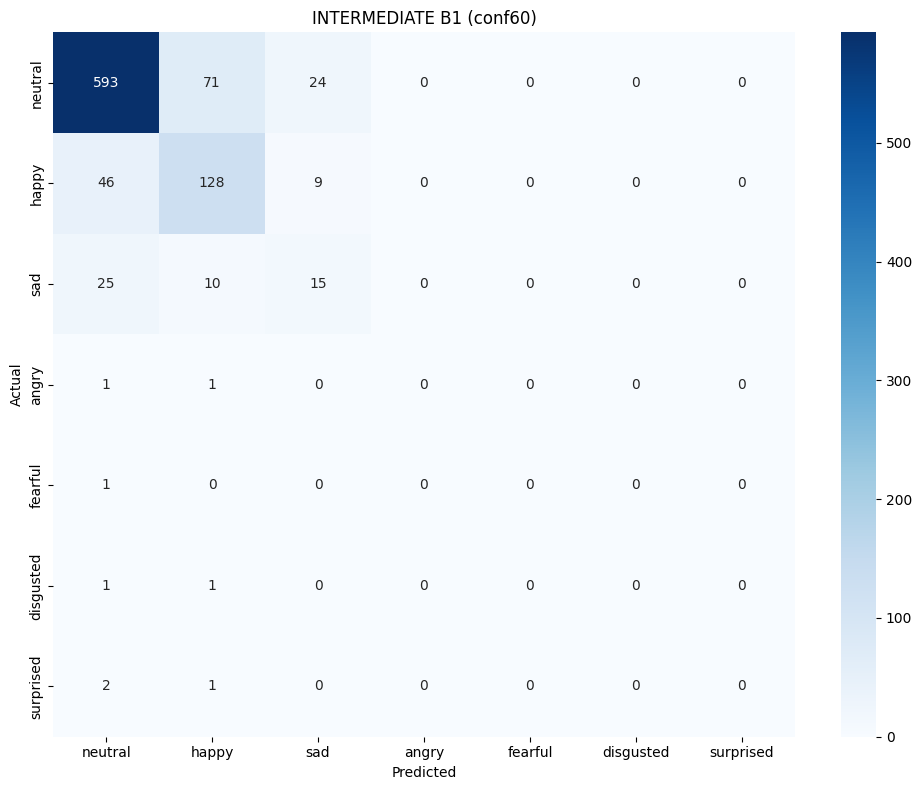

B1: Acc=0.7922 F1=0.2612

Class weights: None


Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1686     0.6913     1.1822    0.8238   0.1291   0.000100  (31.4s)


     2      0.6609     0.8544     0.8849    0.8238   0.1291   0.000100  (31.5s)


     3      0.5645     0.8555     0.7995    0.8221   0.1289   0.000100  (31.6s)


...

    27      0.2061     0.9378     0.9185    0.8152   0.2044   0.000050  (31.6s)


    28      0.1998     0.9353     0.8729    0.8031   0.2051   0.000050  (31.7s)


    29      0.1930     0.9391     0.9754    0.8083   0.2039   0.000050  (31.7s)


    30      0.1830     0.9408     0.8974    0.7720   0.2045   0.000050  (31.7s)


    31      0.1813     0.9380     0.9165    0.7927   0.1939   0.000050  (31.7s)

Early stopping at epoch 31. Best epoch: 16 (val_f1=0.2555)

Best: epoch 16, val_acc=0.8187, val_f1=0.2555
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/intermediate_b2.pth


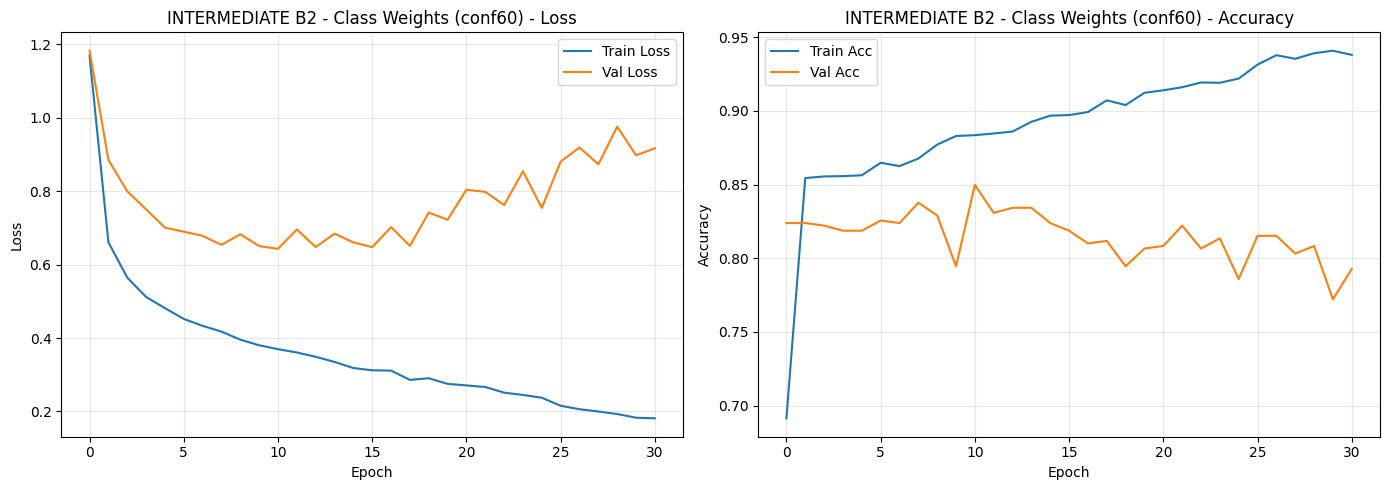

Test Loss: 0.5525
Test Accuracy: 0.7793
Test Macro F1: 0.2469
Test Weighted F1: 0.7843

Classification Report:
              precision    recall  f1-score   support

     neutral       0.92      0.81      0.86       688
       happy       0.57      0.85      0.68       183
         sad       0.18      0.18      0.18        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.78       929
   macro avg       0.24      0.26      0.25       929
weighted avg       0.81      0.78      0.78       929



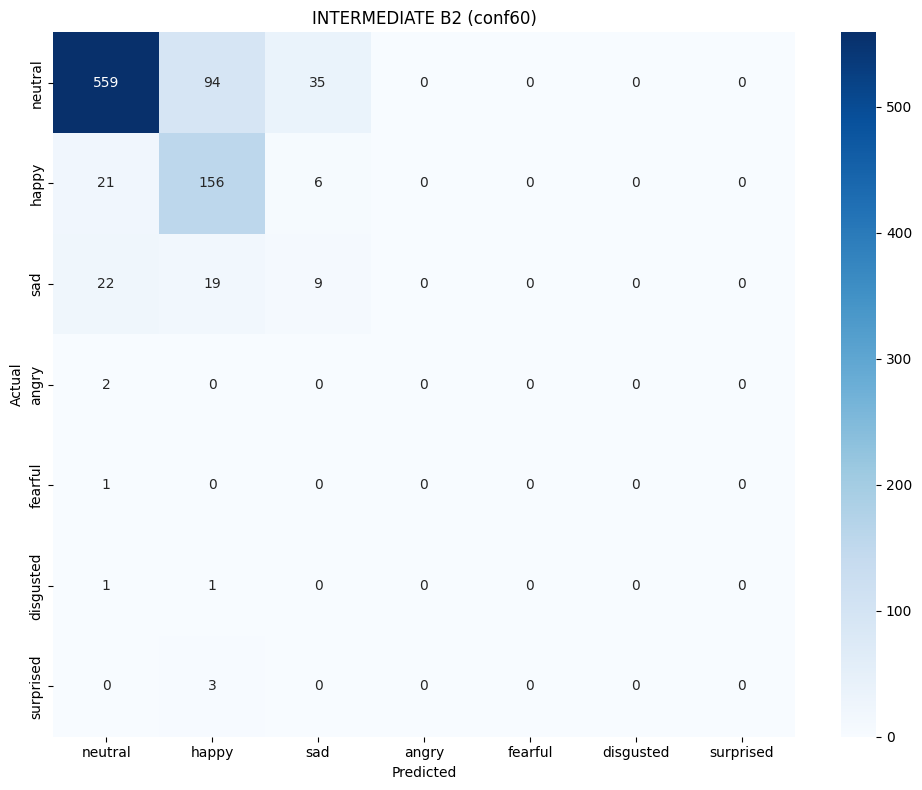

B2: Acc=0.7793 F1=0.2469


Train: 5829 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150



Training B3 (class weights + augmented)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.3493     0.6138     1.1110    0.8238   0.1291   0.000100  (35.8s)


     2      0.8996     0.7749     0.8823    0.8221   0.1289   0.000100  (36.1s)


...

    22      0.2694     0.9082     0.8914    0.7945   0.2128   0.000050  (35.7s)


    23      0.2461     0.9153     0.9402    0.7651   0.2003   0.000050  (35.6s)


    24      0.2296     0.9207     0.9605    0.8100   0.1977   0.000050  (35.4s)


    25      0.2271     0.9221     0.9425    0.7807   0.1894   0.000050  (35.4s)


    26      0.2146     0.9247     1.0053    0.8048   0.1940   0.000050  (35.5s)

Early stopping at epoch 26. Best epoch: 11 (val_f1=0.2369)

Best: epoch 11, val_acc=0.8290, val_f1=0.2369
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/intermediate_b3.pth


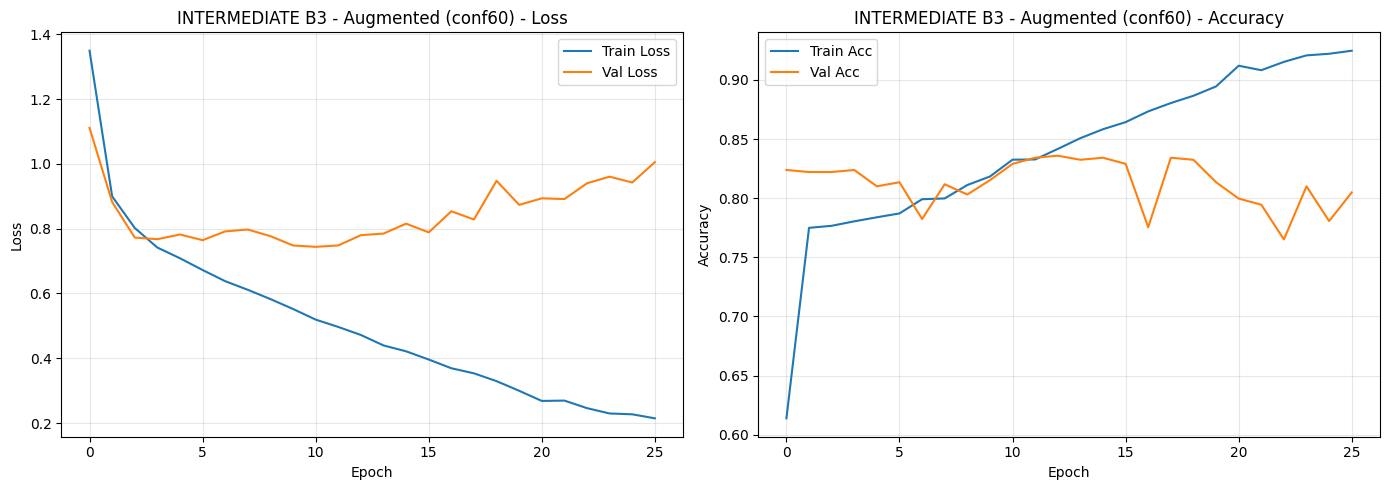

Test Loss: 0.6304
Test Accuracy: 0.7750
Test Macro F1: 0.2294
Test Weighted F1: 0.7541

Classification Report:
              precision    recall  f1-score   support

     neutral       0.82      0.92      0.86       688
       happy       0.65      0.44      0.52       183
         sad       0.28      0.18      0.22        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.78       929
   macro avg       0.25      0.22      0.23       929
weighted avg       0.75      0.78      0.75       929



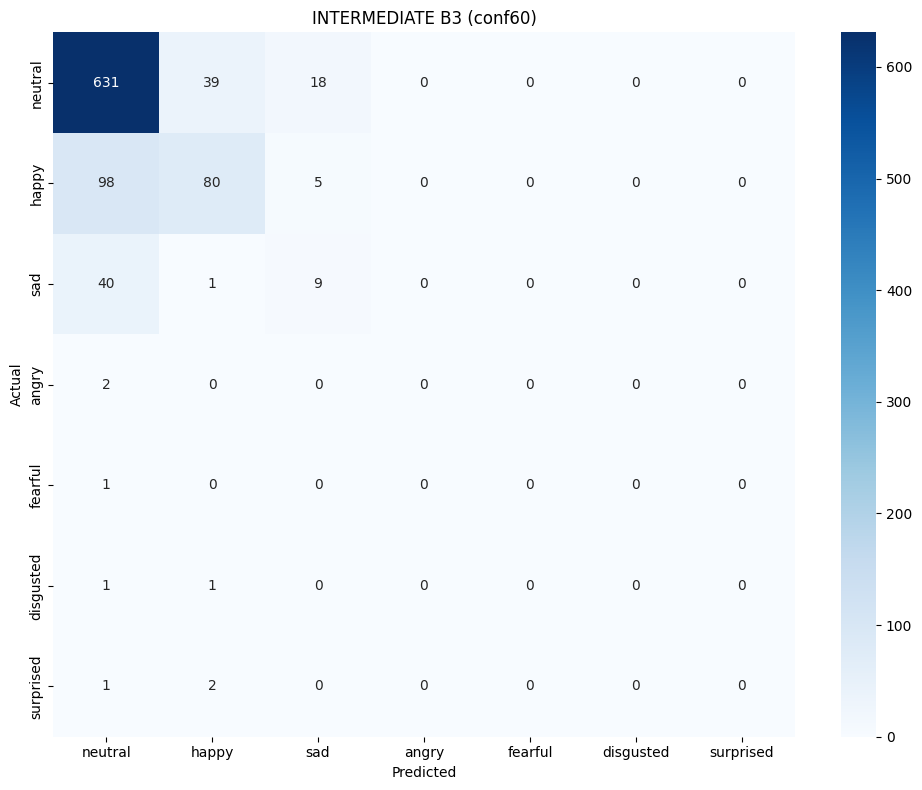

B3: Acc=0.7750 F1=0.2294

RINGKASAN INTERMEDIATE (conf60)
  B1 Baseline               Acc=0.7922 F1=0.2612
  B2 Class Weights          Acc=0.7793 F1=0.2469
  B3 Weights+Aug            Acc=0.7750 F1=0.2294

Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/intermediate_results.json


In [3]:
all_results = {}

# B1: Baseline
model_b1 = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B1 (baseline)...")
history_b1, _ = train_model(model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "intermediate_b1.pth"))
plot_training_history(history_b1, "INTERMEDIATE B1 - Baseline (conf60)")
model_b1.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b1.pth", map_location=device, weights_only=True))
r_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "fusion", EMOTIONS)
plot_confusion_matrix(r_b1["confusion_matrix"], "INTERMEDIATE B1 (conf60)", EMOTIONS)
all_results["B1 Baseline"] = {"accuracy": float(r_b1["test_accuracy"]), "macro_f1": float(r_b1["test_macro_f1"]), "weighted_f1": float(r_b1["test_weighted_f1"])}
print(f"B1: Acc={r_b1['test_accuracy']:.4f} F1={r_b1['test_macro_f1']:.4f}")

# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"\nClass weights: {weights}")
model_b2 = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("Training B2 (class weights)...")
history_b2, _ = train_model(model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "intermediate_b2.pth"))
plot_training_history(history_b2, "INTERMEDIATE B2 - Class Weights (conf60)")
model_b2.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b2.pth", map_location=device, weights_only=True))
r_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "fusion", EMOTIONS)
plot_confusion_matrix(r_b2["confusion_matrix"], "INTERMEDIATE B2 (conf60)", EMOTIONS)
all_results["B2 Class Weights"] = {"accuracy": float(r_b2["test_accuracy"]), "macro_f1": float(r_b2["test_macro_f1"]), "weighted_f1": float(r_b2["test_weighted_f1"])}
print(f"B2: Acc={r_b2['test_accuracy']:.4f} F1={r_b2['test_macro_f1']:.4f}")

# B3: Class Weights + Augmented
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
model_b3 = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B3 (class weights + augmented)...")
history_b3, _ = train_model(model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "intermediate_b3.pth"))
plot_training_history(history_b3, "INTERMEDIATE B3 - Augmented (conf60)")
model_b3.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b3.pth", map_location=device, weights_only=True))
r_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "fusion", EMOTIONS)
plot_confusion_matrix(r_b3["confusion_matrix"], "INTERMEDIATE B3 (conf60)", EMOTIONS)
all_results["B3 Weights+Aug"] = {"accuracy": float(r_b3["test_accuracy"]), "macro_f1": float(r_b3["test_macro_f1"]), "weighted_f1": float(r_b3["test_weighted_f1"])}
print(f"B3: Acc={r_b3['test_accuracy']:.4f} F1={r_b3['test_macro_f1']:.4f}")

# Summary
print("\n" + "=" * 60)
print("RINGKASAN INTERMEDIATE (conf60)")
print("=" * 60)
for name, r in all_results.items():
    print(f"  {name:<25} Acc={r['accuracy']:.4f} F1={r['macro_f1']:.4f}")

with open(OUTPUT_DIR / "intermediate_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nSaved: {OUTPUT_DIR / 'intermediate_results.json'}")